In [2]:
import sys
sys.path.append("../src")

from data_loader import load_movielens_100k
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ratings, movies, users = load_movielens_100k()

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
# Basic dataset statistics

num_users = ratings["user_id"].nunique()
num_movies = ratings["item_id"].nunique()
num_ratings = len(ratings)

sparsity = 1 - (num_ratings / (num_users * num_movies))

print("Number of users:", num_users)
print("Number of movies:", num_movies)
print("Number of ratings:", num_ratings)
print("Sparsity:", round(sparsity, 4))

Number of users: 943
Number of movies: 1682
Number of ratings: 100000
Sparsity: 0.937


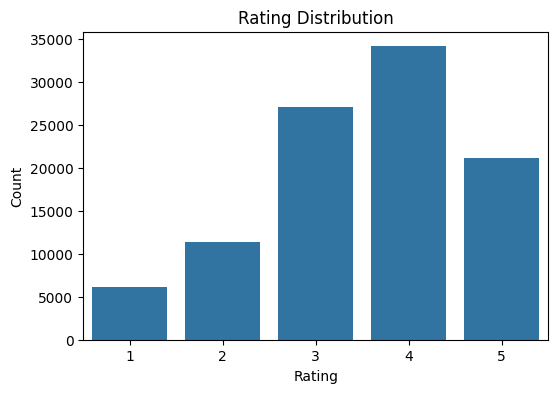

In [4]:
# Rating distribution

plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=ratings)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

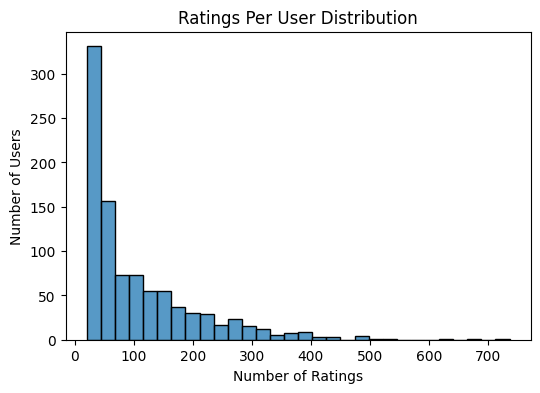

In [5]:
# Ratings per user

ratings_per_user = ratings.groupby("user_id").size()

plt.figure(figsize=(6,4))
sns.histplot(ratings_per_user, bins=30)
plt.title("Ratings Per User Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

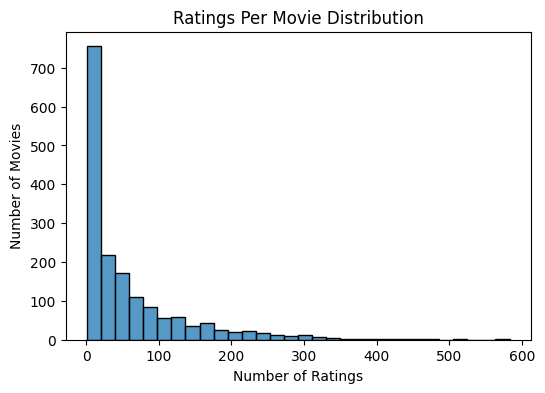

In [6]:
# Ratings per movie (movie popularity)

ratings_per_movie = ratings.groupby("item_id").size()

plt.figure(figsize=(6,4))
sns.histplot(ratings_per_movie, bins=30)
plt.title("Ratings Per Movie Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

## Train / Validation / Test Split

In [7]:
from preprocessing import train_validation_test_split, save_splits

train, val, test = train_validation_test_split(ratings)

print("Train size:", len(train))
print("Validation size:", len(val))
print("Test size:", len(test))

save_splits(train, val, test)

Train size: 80000
Validation size: 10000
Test size: 10000
Splits saved successfully.
